<a href="https://colab.research.google.com/github/Saifullah785/machine-learning-engineer-roadmap/blob/main/Lecture_73_Support_Vector_Machines_SVM/Lecture_73_Kernel_Trick_SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Lecture_73_Support_Vector_Machines_SVM**



In [2]:
# Import necessary libraries for data manipulation, plotting, and SVM.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.axes._axes import _log as matplotlib_axes_logger
from mpl_toolkits import mplot3d
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from matplotlib.colors import ListedColormap

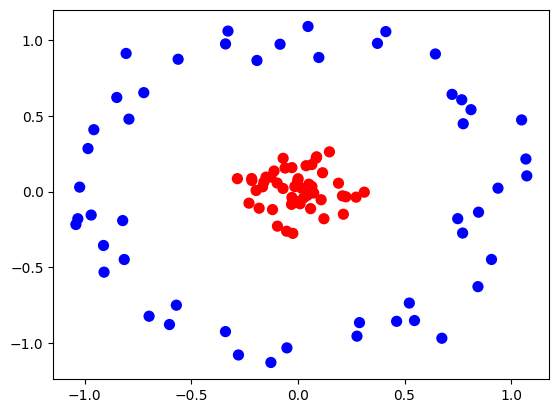

In [3]:
# Generate synthetic data using make_circles and visualize it.
from sklearn.datasets import make_circles
X, y = make_circles(100, factor=.1, noise=.1)

# Plot the generated data with different colors for each class.
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='bwr')

In [4]:
# Split the data into training and testing sets.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.20)

In [5]:
# Initialize and train a linear SVM classifier.
classifier = SVC(kernel='linear')
classifier.fit(X_train, y_train.ravel())

SVC(kernel='linear')

In [6]:
# Make predictions on the test data using the trained linear SVM classifier.
y_pred = classifier.predict(X_test)

In [7]:
# Calculate and display the accuracy of the linear SVM classifier.
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.5

In [8]:
# Define a function to plot the decision boundary of a classifier.
zero_one_colourmap = ListedColormap(('blue', 'red'))
def plot_decision_boundary(X, y, clf):
    # Set up the meshgrid for plotting the decision boundary.
    X_set, y_set = X, y
    X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 1,
                                 stop = X_set[:, 0].max() + 1,
                                 step = 0.01),
                       np.arange(start = X_set[:, 1].min() - 1,
                                 stop = X_set[:, 1].max() + 1,
                                 step = 0.01))

    # Plot the contour of the decision boundary.
    plt.contourf(X1, X2, clf.predict(np.array([X1.ravel(),
                                             X2.ravel()]).T).reshape(X1.shape),
               alpha = 0.75,
               cmap = zero_one_colourmap)
    # Set the limits for the axes.
    plt.xlim(X1.min(), X1.max())
    plt.ylim(X2.min(), X2.max())
    # Plot the data points with different colors for each class.
    for i, j in enumerate(np.unique(y_set)):
        plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                c = (zero_one_colourmap)(i), label = j)
    # Add title and labels to the plot.
    plt.title('SVM Decision Boundary')
    plt.xlabel('X1')
    plt.ylabel('X2')
    plt.legend()
    return plt.show()

/tmp/ipython-input-3265480270.py:19: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


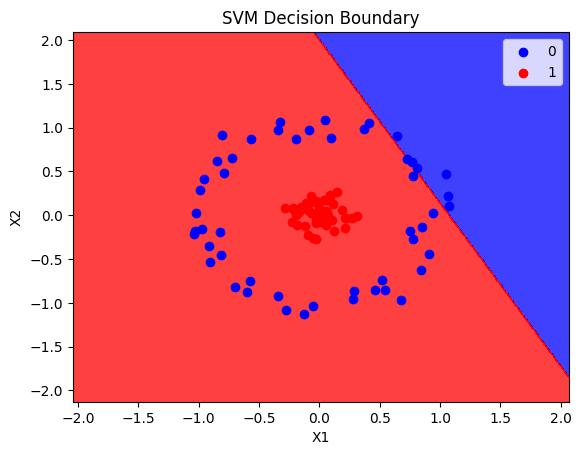

In [9]:
# Plot the decision boundary for the linear SVM classifier on the generated data.
plot_decision_boundary(X, y, classifier)

In [10]:
# Define a function to create a 3D plot of the data with an added dimension based on the radial basis function.
def plot_3d_plot(X, y):
  # Calculate the new dimension 'r' using the radial basis function.
  r = np.exp(-(X ** 2).sum(1))
  # Create a 3D scatter plot.
  ax = plt.subplot(projection='3d')
  ax.scatter3D(X[:, 0], X[:, 1], r, c=y, s=100, cmap='bwr')
  # Set labels for the axes.
  ax.set_xlabel('X1')
  ax.set_ylabel('Y1')
  ax.set_zlabel('y')
  return ax

<Axes3D: xlabel='X1', ylabel='Y1', zlabel='y'>

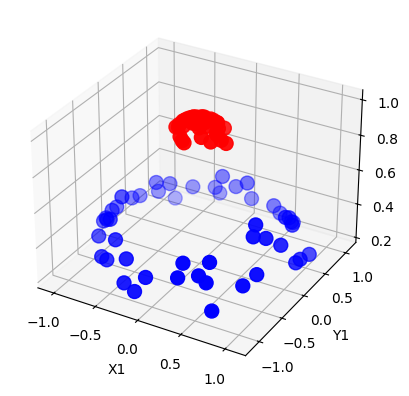

In [11]:
# Create and display the 3D plot of the data.
plot_3d_plot(X, y)

In [12]:
# Initialize and train an RBF kernel SVM classifier.
rbf_classifier = SVC(kernel='rbf')
rbf_classifier.fit(X_train, y_train)

SVC()

In [13]:
# Make predictions on the test data using the trained RBF kernel SVM classifier.
y_pred = rbf_classifier.predict(X_test)

In [14]:
# Calculate and display the accuracy of the RBF kernel SVM classifier.
accuracy_score(y_test, y_pred)

1.0

/tmp/ipython-input-3265480270.py:19: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


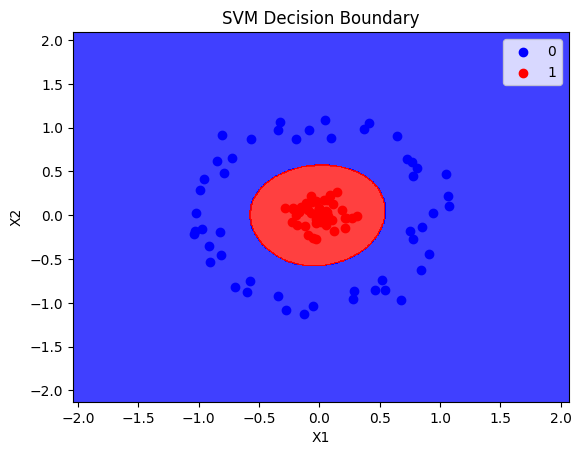

In [15]:
# Plot the decision boundary for the RBF kernel SVM classifier on the generated data.
plot_decision_boundary(X, y, rbf_classifier)

In [16]:
# Initialize and train a polynomial kernel SVM classifier with degree 2.
poly_calssifier = SVC(kernel='poly',degree=2)
poly_calssifier.fit(X_train, y_train)

SVC(degree=2, kernel='poly')

In [18]:
# Make predictions on the test data using the trained polynomial kernel SVM classifier.
y_pred = poly_calssifier.predict(X_test)
# Calculate and display the accuracy of the polynomial kernel SVM classifier.
accuracy_score(y_test, y_pred)

1.0

/tmp/ipython-input-3265480270.py:19: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


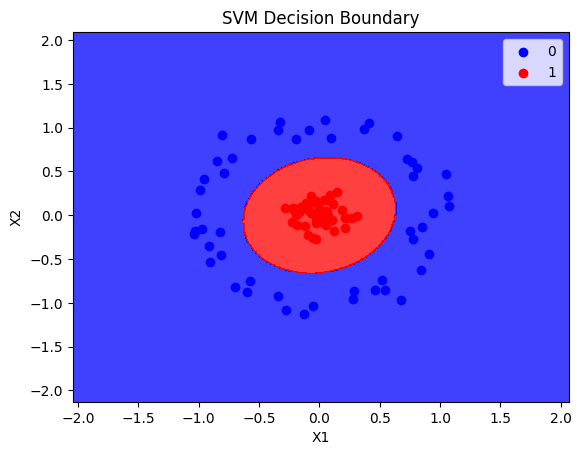

In [19]:
# Plot the decision boundary for the polynomial kernel SVM classifier on the generated data.
plot_decision_boundary(X, y, poly_calssifier)

In [20]:
# Display the original data X.
X

array([[ 6.75200231e-01, -9.69085242e-01],
       [-8.22121739e-01, -1.91297397e-01],
       [-1.04167057e+00, -2.17117598e-01],
       [ 1.01489581e-02, -7.99308397e-02],
       [ 6.52341419e-02,  1.79371721e-01],
       [-9.70002319e-01, -1.54619155e-01],
       [-3.39642069e-01,  9.76545196e-01],
       [ 4.12415515e-01,  1.05803970e+00],
       [ 6.44795958e-01,  9.10213603e-01],
       [ 1.07371689e+00,  1.04307355e-01],
       [ 9.80264793e-02,  8.86960029e-01],
       [-5.30881263e-02, -2.61666924e-01],
       [ 5.14958105e-02,  4.94140613e-02],
       [-2.79062741e-01, -1.07966311e+00],
       [-9.57481636e-01,  4.09679728e-01],
       [ 4.66346438e-02,  1.62474881e-02],
       [ 5.46809559e-01, -8.52106204e-01],
       [-1.19272313e-01, -1.18508673e-01],
       [ 7.23188446e-01,  6.43210779e-01],
       [-1.81951701e-01, -1.09482382e-01],
       [-1.12111053e-01,  1.36391312e-01],
       [ 7.75395728e-01,  4.48947797e-01],
       [-1.96336778e-01,  7.69602087e-03],
       [-1.

In [21]:
# Calculate the result of applying the radial basis function to each data point in X.
np.exp(-(X**2)).sum(1)

array([1.02484948, 1.47277325, 1.29182936, 1.99352843, 1.96409142,
       1.3666511 , 1.27638386, 1.17005174, 1.09654615, 1.30490892,
       1.44578266, 1.93100749, 1.99491292, 1.23679211, 1.24529914,
       1.99756363, 1.22535826, 1.97192868, 1.25392474, 1.95552076,
       1.96907914, 1.36559167, 1.96212617, 1.99503148, 1.12152952,
       1.94069774, 1.95653413, 1.28662391, 1.99446499, 1.94950862,
       1.99539616, 1.99468617, 1.4351254 , 1.34956309, 1.94286636,
       1.96135462, 1.99748612, 1.92687629, 1.24539663, 1.91511974,
       1.30104464, 1.32804943, 1.91147598, 1.26278435, 1.34144278,
       1.99542006, 1.2218023 , 1.99456229, 1.39251502, 1.98735785,
       1.15760394, 1.32762665, 1.92615843, 1.97127375, 1.24430102,
       1.34239953, 1.31629794, 1.9976108 , 1.93355063, 1.16442856,
       1.33253767, 0.95611721, 1.41393252, 1.94654224, 1.95371566,
       1.37986799, 1.9853613 , 1.97078847, 1.97425595, 1.99273561,
       1.99772974, 1.26341026, 1.53864132, 1.19056832, 1.99207

In [22]:
# Create a new dataset by applying the radial basis function to each data point in X.
X_new = np.exp(-(X**2))

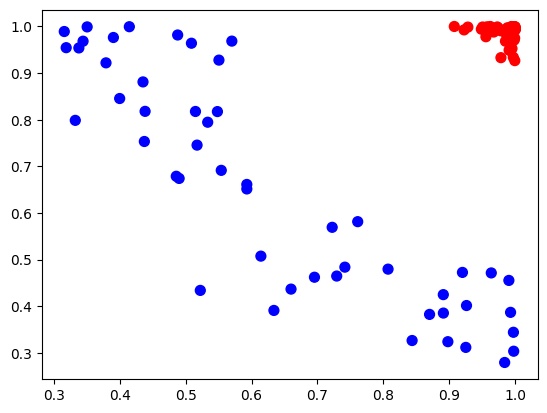

In [23]:
# Plot the new dataset X_new with different colors for each class.
plt.scatter(X_new[:, 0], X_new[:, 1], c=y, s=50, cmap='bwr')